# 🔬 Perbandingan RF, Decision Tree & Logistic Regression
## Klasifikasi Potensi Keberhasilan Imunoterapi pada Kanker Ovarium

---
| | |
|---|---|
| **Label** | Dibuat dari TMB + MSIsensor Score (biomarker imunoterapi klinis) |
| **Algoritma** | Random Forest · Decision Tree · Logistic Regression |
| **Anti-Leakage** | TMB & MSI dihapus dari fitur training setelah pembuatan label |


## 📦 Sel 1 — Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, roc_auc_score, confusion_matrix,
    ConfusionMatrixDisplay, roc_curve, classification_report
)

print("✅ Semua library berhasil diimport!")


✅ Semua library berhasil diimport!


## 💾 Sel 2 — Mount Google Drive & Cek Ketersediaan File

In [2]:
from google.colab import drive
drive.mount('/content/drive')

# ─── SESUAIKAN PATH FOLDER KAMU ──────────────────────────────────
DRIVE_BASE = '/content/drive/MyDrive/randomforest/data'  # ← ganti ini!

OUTPUT_DIR = f"{DRIVE_BASE}/hasil_penelitian"
os.makedirs(OUTPUT_DIR, exist_ok=True)

# File yang dibutuhkan
FILES_NEEDED = {
    'TCGA Clinical Data': 'ov_tcga_clinicaldata.tsv',   # ← sesuaikan nama file!
}

print("=" * 60)
print("📁 CEK KETERSEDIAAN DATASET")
print("=" * 60)

if not os.path.exists(DRIVE_BASE):
    print(f"\n❌ FOLDER TIDAK DITEMUKAN: {DRIVE_BASE}")
    print("\n💡 Folder yang ada di MyDrive:")
    for f in sorted(os.listdir('/content/drive/MyDrive')):
        print(f"   📁 {f}")
else:
    print(f"\n✅ Folder ditemukan!")
    print(f"\n{'Status':<6} {'Dataset':<25} {'File':<35} {'Ukuran':>8}")
    print("-" * 78)
    all_ok = True
    for label, filename in FILES_NEEDED.items():
        fp = f"{DRIVE_BASE}/{filename}"
        if os.path.exists(fp):
            mb = os.path.getsize(fp) / (1024*1024)
            print(f"  ✅   {label:<25} {filename:<35} {mb:>5.2f} MB")
        else:
            print(f"  ❌   {label:<25} {filename:<35} {'TIDAK ADA':>8}")
            all_ok = False
    print("-" * 78)
    print("\n📂 Semua file di folder:")
    for f in sorted(os.listdir(DRIVE_BASE)):
        mb = os.path.getsize(f"{DRIVE_BASE}/{f}") / (1024*1024)
        print(f"   {'📄' if '.' in f else '📁'}  {f:<45} {mb:>6.2f} MB")
    print()
    if all_ok:
        print("✅ Semua file tersedia! Lanjut ke Sel 3.")
    else:
        print("⚠️  Sesuaikan nama file di FILES_NEEDED!")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
📁 CEK KETERSEDIAAN DATASET

✅ Folder ditemukan!

Status Dataset                   File                                  Ukuran
------------------------------------------------------------------------------
  ✅   TCGA Clinical Data        ov_tcga_clinicaldata.tsv             0.27 MB
------------------------------------------------------------------------------

📂 Semua file di folder:
   📁  GEO                                             0.00 MB
   📄  HiSeqV2.csv                                    43.64 MB
   📄  HumanMethylation27.csv                        107.48 MB
   📄  OV_clinicalMatrix.tsv                           0.56 MB
   📄  Ovarian_patient_data.csv                       69.98 MB
   📄  REFCHEMRefChemID422(1).xml                      0.20 MB
   📄  X_preprocessed.csv                              0.38 MB
   📄  analisis_obat_permodel.csv                  

## 📂 Sel 3 — Load Dataset TCGA

In [3]:
TCGA_PATH = f"{DRIVE_BASE}/{FILES_NEEDED['TCGA Clinical Data']}"

df_raw = pd.read_csv(TCGA_PATH, sep='\t')

print("✅ Dataset berhasil dimuat!")
print(f"\n📊 Ukuran : {df_raw.shape[0]} baris  x  {df_raw.shape[1]} kolom")
print(f"\n📋 Semua kolom ({len(df_raw.columns)} kolom):")
for i, col in enumerate(df_raw.columns, 1):
    print(f"   {i:3}. {col}")


✅ Dataset berhasil dimuat!

📊 Ukuran : 585 baris  x  63 kolom

📋 Semua kolom (63 kolom):
     1. Study ID
     2. Patient ID
     3. Sample ID
     4. Diagnosis Age
     5. Neoplasm Disease Stage American Joint Committee on Cancer Code
     6. American Joint Committee on Cancer Publication Version Type
     7. Aneuploidy Score
     8. Buffa Hypoxia Score
     9. Cancer Type
    10. TCGA PanCanAtlas Cancer Type Acronym
    11. Cancer Type Detailed
    12. Last Communication Contact from Initial Pathologic Diagnosis Date
    13. Birth from Initial Pathologic Diagnosis Date
    14. Last Alive Less Initial Pathologic Diagnosis Date Calculated Day Value
    15. Disease Free (Months)
    16. Disease Free Status
    17. Months of disease-specific survival
    18. Disease-specific Survival status
    19. Ethnicity Category
    20. Form completion date
    21. Fraction Genome Altered
    22. Genetic Ancestry Label
    23. Neoplasm Histologic Grade
    24. Neoadjuvant Therapy Type Administered P

## 🔍 Sel 4 — Eksplorasi Data Awal (EDA)

In [4]:
print("=" * 60)
print("5 BARIS PERTAMA")
print("=" * 60)
display(df_raw.head())

print("\n" + "=" * 60)
print("TIPE DATA & INFO")
print("=" * 60)
df_raw.info()

print("\n" + "=" * 60)
print("STATISTIK DESKRIPTIF")
print("=" * 60)
display(df_raw.describe())


5 BARIS PERTAMA


,Study ID,Patient ID,Sample ID,Diagnosis Age,Neoplasm Disease Stage American Joint Committee on Cancer Code,American Joint Committee on Cancer Publication Version Type,Aneuploidy Score,Buffa Hypoxia Score,Cancer Type,TCGA PanCanAtlas Cancer Type Acronym,...,Tumor Break Load,Tissue Prospective Collection Indicator,Tissue Retrospective Collection Indicator,Tissue Source Site,Tissue Source Site Code,TMB (nonsynonymous),Tumor Disease Anatomic Site,Tumor Type,Patient Weight,Winter Hypoxia Score
0,ov_tcga_pan_can_atlas_2018,TCGA-04-1331,TCGA-04-1331-01,78.0,NaN,NaN,7.0,NaN,Ovarian Epithelial Tumor,OV,...,109.0,NaN,NaN,Gynecologic Oncology Group,4,4.500000,Ovary,Serous Cystadenocarcinoma,NaN,NaN
1,ov_tcga_pan_can_atlas_2018,TCGA-04-1332,TCGA-04-1332-01,70.0,NaN,NaN,15.0,NaN,Ovarian Epithelial Tumor,OV,...,158.0,NaN,NaN,Gynecologic Oncology Group,4,NaN,Ovary,Serous Cystadenocarcinoma,NaN,NaN
2,ov_tcga_pan_can_atlas_2018,TCGA-04-1335,TCGA-04-1335-01,60.0,NaN,NaN,6.0,NaN,Ovarian Epithelial Tumor,OV,...,46.0,NaN,NaN,Gynecologic Oncology Group,4,0.500000,Ovary,Serous Cystadenocarcinoma,NaN,NaN
3,ov_tcga_pan_can_atlas_2018,TCGA-04-1336,TCGA-04-1336-01,55.0,NaN,NaN,7.0,NaN,Ovarian Epithelial Tumor,OV,...,87.0,NaN,NaN,Gynecologic Oncology Group,4,2.233333,Ovary,Serous Cystadenocarcinoma,NaN,NaN
4,ov_tcga_pan_can_atlas_2018,TCGA-04-1337,TCGA-04-1337-01,78.0,NaN,NaN,15.0,NaN,Ovarian Epithelial Tumor,OV,...,71.0,NaN,NaN,Gynecologic Oncology Group,4,0.000000,Ovary,Serous Cystadenocarcinoma,NaN,NaN



TIPE DATA & INFO
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 585 entries, 0 to 584
Data columns (total 63 columns):
 #   Column                                                                                       Non-Null Count  Dtype  
---  ------                                                                                       --------------  -----  
 0   Study ID                                                                                     585 non-null    object 
 1   Patient ID                                                                                   585 non-null    object 
 2   Sample ID                                                                                    585 non-null    object 
 3   Diagnosis Age                                                                                483 non-null    float64
 4   Neoplasm Disease Stage American Joint Committee on Cancer Code                               0 non-null      float64
 5   American Joint Com

,Diagnosis Age,Neoplasm Disease Stage American Joint Committee on Cancer Code,American Joint Committee on Cancer Publication Version Type,Aneuploidy Score,Buffa Hypoxia Score,Last Communication Contact from Initial Pathologic Diagnosis Date,Birth from Initial Pathologic Diagnosis Date,Last Alive Less Initial Pathologic Diagnosis Date Calculated Day Value,Disease Free (Months),Months of disease-specific survival,...,Neoplasm Disease Lymph Node Stage American Joint Committee on Cancer Code,American Joint Committee on Cancer Tumor Stage Code,Progress Free Survival (Months),Primary Lymph Node Presentation Assessment,Ragnum Hypoxia Score,Number of Samples Per Patient,Tumor Break Load,TMB (nonsynonymous),Patient Weight,Winter Hypoxia Score
count,483.000000,0.0,0.0,552.000000,300.000000,428.000000,472.000000,483.0,282.000000,571.000000,...,0.0,0.0,571.000000,0.0,300.000000,585.0,580.000000,523.000000,0.0,300.000000
mean,59.619048,NaN,NaN,13.978261,10.433333,1026.693925,-21958.798729,0.0,27.522053,38.920592,...,NaN,NaN,21.886784,NaN,6.706667,1.0,239.648276,2.314532,NaN,9.253333
std,11.565967,NaN,NaN,7.147873,14.045753,870.391009,4223.305789,0.0,26.547963,30.636361,...,NaN,NaN,22.983822,NaN,8.007143,0.0,194.423324,3.727006,NaN,15.990041
min,26.000000,NaN,NaN,0.000000,-33.000000,0.000000,-32853.000000,0.0,1.084920,0.263011,...,NaN,NaN,0.263011,NaN,-20.000000,1.0,0.000000,0.000000,NaN,-38.000000
25%,51.000000,NaN,NaN,8.000000,1.000000,308.500000,-24996.750000,0.0,11.375218,15.714896,...,NaN,NaN,8.547852,NaN,2.000000,1.0,125.750000,0.566667,NaN,-2.000000
50%,59.000000,NaN,NaN,13.000000,12.000000,864.500000,-21567.500000,0.0,18.608015,33.303745,...,NaN,NaN,14.695729,NaN,8.000000,1.0,199.500000,1.866667,NaN,10.000000
75%,68.000000,NaN,NaN,20.000000,21.000000,1473.500000,-18766.250000,0.0,32.958543,54.903508,...,NaN,NaN,26.777789,NaN,12.000000,1.0,292.000000,2.933333,NaN,20.000000
max,89.000000,NaN,NaN,31.000000,37.000000,5481.000000,-9760.000000,0.0,180.195286,180.195286,...,NaN,NaN,180.195286,NaN,22.000000,1.0,1833.000000,63.433333,NaN,46.000000


## 🔎 Sel 5 — Cek Missing Values

Kolom dengan missing values: 49 dari 63 kolom



,Missing Count,Missing (%)
Neoplasm Disease Stage American Joint Committee on Cancer Code,585,100.00
American Joint Committee on Cancer Publication Version Type,585,100.00
Patient Weight,585,100.00
American Joint Committee on Cancer Tumor Stage Code,585,100.00
Primary Lymph Node Presentation Assessment,585,100.00
Neoplasm Disease Lymph Node Stage American Joint Committee on Cancer Code,585,100.00
American Joint Committee on Cancer Metastasis Stage Code,585,100.00
Prior Diagnosis,574,98.12
Tissue Prospective Collection Indicator,568,97.09
Tissue Retrospective Collection Indicator,568,97.09


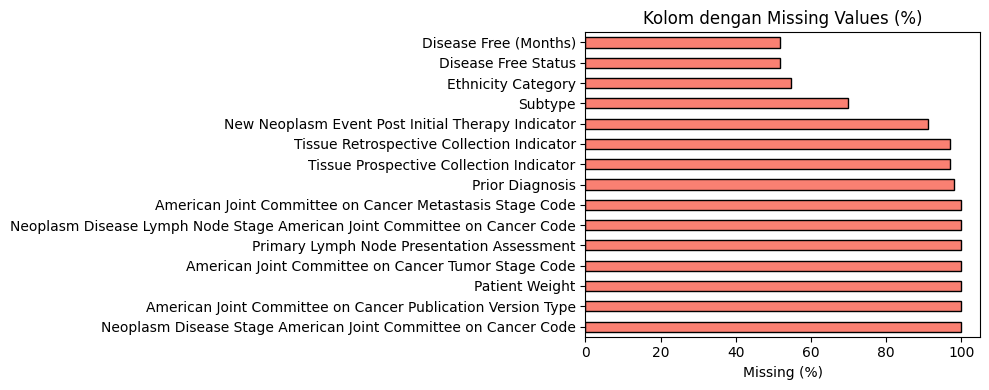

In [5]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({
    'Missing Count': missing,
    'Missing (%)': missing_pct
}).sort_values('Missing (%)', ascending=False)
missing_df = missing_df[missing_df['Missing Count'] > 0]

print(f"Kolom dengan missing values: {len(missing_df)} dari {len(df_raw.columns)} kolom\n")
display(missing_df)

# Visualisasi
if len(missing_df) > 0:
    plt.figure(figsize=(10, 4))
    missing_df.head(15)['Missing (%)'].plot(kind='barh', color='salmon', edgecolor='black')
    plt.title('Kolom dengan Missing Values (%)')
    plt.xlabel('Missing (%)')
    plt.tight_layout()
    plt.savefig(f"{OUTPUT_DIR}/missing_values.png", dpi=150, bbox_inches='tight')
    plt.show()


# Sel 6 Hapus Fitur-fitur yang tidak di perlukan

In [6]:
# ============================================================
# PILIH FITUR YANG DIGUNAKAN
# ============================================================

selected_cols = [
    'Diagnosis Age',
    'Sex',
    'Neoplasm Histologic Grade',
    'MSI MANTIS Score',
    'MSIsensor Score',
    'TMB (nonsynonymous)',
    'Mutation Count',
    'Aneuploidy Score',
    'Fraction Genome Altered',
    'Tumor Break Load',
    'Radiation Therapy',
    'Race Category'
]

# Ambil hanya kolom yang tersedia
selected_cols = [col for col in selected_cols if col in df_raw.columns]

df_tcga = df_raw[selected_cols].copy()
# ============================================================
# IMPUTASI MISSING VALUE
# ============================================================
from sklearn.impute import SimpleImputer

# Pisahkan kolom numerik dan kategorik
num_cols = [
    'Diagnosis Age', 'MSI MANTIS Score', 'MSIsensor Score',
    'TMB (nonsynonymous)', 'Mutation Count', 'Aneuploidy Score',
    'Fraction Genome Altered', 'Tumor Break Load'
]

cat_cols = [
    'Sex', 'Neoplasm Histologic Grade', 'Radiation Therapy', 'Race Category'
]

# Imputasi numerik dengan median
num_imputer = SimpleImputer(strategy='median')
df_tcga[num_cols] = num_imputer.fit_transform(df_tcga[num_cols])

# Imputasi kategorik dengan modus
cat_imputer = SimpleImputer(strategy='most_frequent')
df_tcga[cat_cols] = cat_imputer.fit_transform(df_tcga[cat_cols])

# Cek hasil
print("📊 Missing Value Setelah Imputasi")
print(df_tcga.isnull().sum())
print(f"\nTotal sampel tersedia: {len(df_tcga)}")
# ============================================================
# CEK MISSING VALUE
# ============================================================

missing_summary = pd.DataFrame({
    'Missing Count': df_tcga.isnull().sum(),
    'Missing (%)': round(df_tcga.isnull().mean() * 100, 2)
}).sort_values('Missing (%)', ascending=False)

print("📊 Missing Value Sebelum Imputasi")
display(missing_summary)



📊 Missing Value Setelah Imputasi
Diagnosis Age                0
Sex                          0
Neoplasm Histologic Grade    0
MSI MANTIS Score             0
MSIsensor Score              0
TMB (nonsynonymous)          0
Mutation Count               0
Aneuploidy Score             0
Fraction Genome Altered      0
Tumor Break Load             0
Radiation Therapy            0
Race Category                0
dtype: int64

Total sampel tersedia: 585
📊 Missing Value Sebelum Imputasi


,Missing Count,Missing (%)
Diagnosis Age,0,0.0
Sex,0,0.0
Neoplasm Histologic Grade,0,0.0
MSI MANTIS Score,0,0.0
MSIsensor Score,0,0.0
TMB (nonsynonymous),0,0.0
Mutation Count,0,0.0
Aneuploidy Score,0,0.0
Fraction Genome Altered,0,0.0
Tumor Break Load,0,0.0


## 🏷️ Sel 6 — Buat Label: Immunotherapy Response Potential

### Dasar Pembuatan Label
Label dibuat dari **2 biomarker imunoterapi yang diakui klinis (FDA)**:

| Biomarker | Kolom TCGA | Threshold | Referensi |
|---|---|---|---|
| **TMB** (Tumor Mutational Burden) | `TMB (nonsynonymous)` | ≥ 10 mut/Mb = High | FDA Approval 2020 |
| **MSI** (Microsatellite Instability) | `MSIsensor Score` | ≥ 4 = MSI-High | Bonneville et al. 2017 |

**Aturan Label:**
- `1 = Berpotensi Berhasil` → TMB High **ATAU** MSI-High
- `0 = Tidak Berpotensi` → TMB Low **DAN** MSI-Low

> ⚠️ **Anti-Leakage:** Setelah label dibuat, TMB & MSI akan **dihapus dari fitur training**


In [7]:
# ─── Nama kolom TMB dan MSI di dataset TCGA ─────────────────────
# Sesuaikan jika nama kolom berbeda (cek output Sel 3)
COL_TMB = 'TMB (nonsynonymous)'
COL_MSI = 'MSIsensor Score'

# Cek apakah kolom ada
print("Cek kolom biomarker:")
for col in [COL_TMB, COL_MSI]:
    ada = col in df_raw.columns
    print(f"   {'✅' if ada else '❌'}  '{col}'")

# Ambil nilai TMB dan MSI, drop baris yang keduanya NaN
df_label = df_raw[[COL_TMB, COL_MSI]].copy()
df_label_clean = df_label.dropna(subset=[COL_TMB, COL_MSI])
print(f"\nSampel dengan TMB & MSI lengkap: {len(df_label_clean)} dari {len(df_raw)}")

# Distribusi sebelum threshold
print(f"\nDistribusi TMB:")
print(f"   Min    : {df_label_clean[COL_TMB].min():.2f}")
print(f"   Median : {df_label_clean[COL_TMB].median():.2f}")
print(f"   Max    : {df_label_clean[COL_TMB].max():.2f}")
print(f"   >= 10  : {(df_label_clean[COL_TMB] >= 10).sum()} sampel")

print(f"\nDistribusi MSIsensor Score:")
print(f"   Min    : {df_label_clean[COL_MSI].min():.2f}")
print(f"   Median : {df_label_clean[COL_MSI].median():.2f}")
print(f"   Max    : {df_label_clean[COL_MSI].max():.2f}")
print(f"   >= 4   : {(df_label_clean[COL_MSI] >= 4).sum()} sampel")


Cek kolom biomarker:
   ✅  'TMB (nonsynonymous)'
   ✅  'MSIsensor Score'

Sampel dengan TMB & MSI lengkap: 482 dari 585

Distribusi TMB:
   Min    : 0.00
   Median : 2.05
   Max    : 63.43
   >= 10  : 4 sampel

Distribusi MSIsensor Score:
   Min    : 0.00
   Median : 0.83
   Max    : 31.91
   >= 4   : 7 sampel


## 📊 Sel 7 — Terapkan Threshold & Visualisasi Distribusi Label

DISTRIBUSI LABEL IMMUNOTHERAPY RESPONSE POTENTIAL
  1 = Berpotensi Berhasil  :  220 sampel (45.6%)
  0 = Tidak Berpotensi     :  262 sampel (54.4%)
  Total                    :  482 sampel

  Breakdown label positif (1):
   TMB High saja    : 95 sampel
   MSI High saja    : 89 sampel
   Keduanya High    : 36 sampel


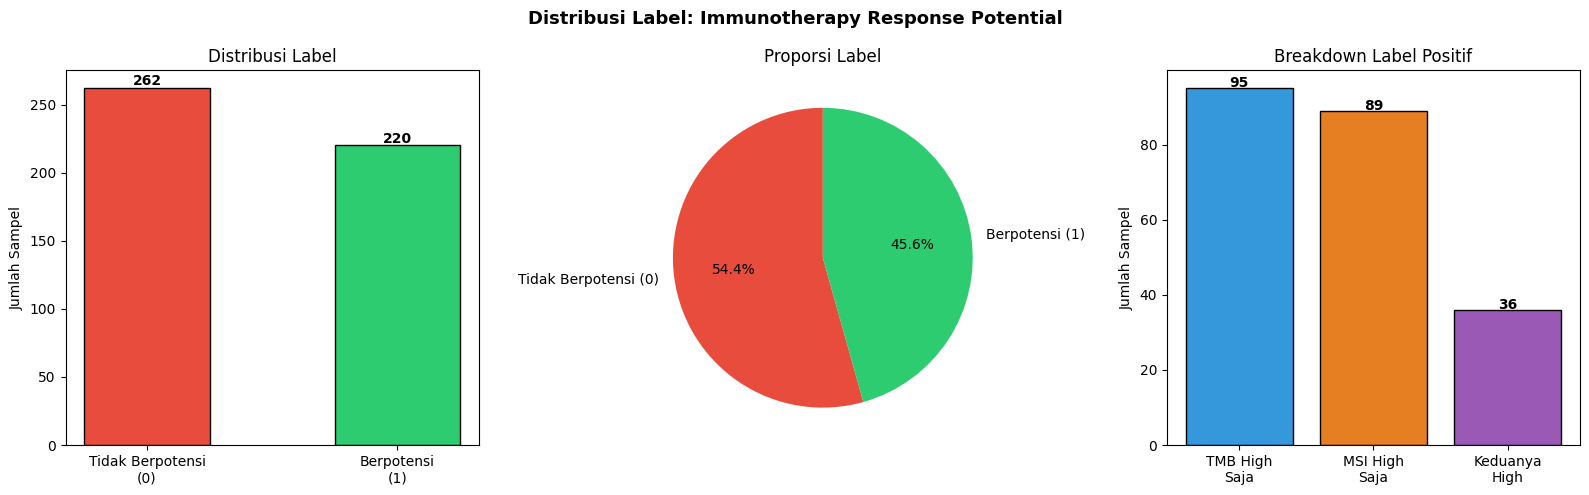

In [8]:
# ─── Threshold (bisa disesuaikan) ───────────────────────────────
TMB_THRESHOLD = df_raw[COL_TMB].dropna().quantile(0.75)# mut/Mb — standar FDA
MSI_THRESHOLD = df_raw[COL_MSI].dropna().quantile(0.75) # standar Bonneville et al.

# Buat label pada df_raw
df_raw['TMB_High'] = (df_raw[COL_TMB] >= TMB_THRESHOLD).astype(int)
df_raw['MSI_High'] = (df_raw[COL_MSI] >= MSI_THRESHOLD).astype(int)

# Label: 1 jika TMB High ATAU MSI High
df_raw['immunotherapy_response'] = (
    (df_raw['TMB_High'] == 1) | (df_raw['MSI_High'] == 1)
).astype(int)

# Drop baris yang TMB atau MSI kosong (tidak bisa diberi label valid)
df_labeled = df_raw.dropna(subset=[COL_TMB, COL_MSI]).copy()
df_labeled['immunotherapy_response'] = (
    (df_labeled[COL_TMB] >= TMB_THRESHOLD) |
    (df_labeled[COL_MSI] >= MSI_THRESHOLD)
).astype(int)

# Ringkasan label
label_counts = df_labeled['immunotherapy_response'].value_counts()
n_total = len(df_labeled)
n_pos = label_counts.get(1, 0)
n_neg = label_counts.get(0, 0)

print("=" * 55)
print("DISTRIBUSI LABEL IMMUNOTHERAPY RESPONSE POTENTIAL")
print("=" * 55)
print(f"  1 = Berpotensi Berhasil  : {n_pos:>4} sampel ({n_pos/n_total*100:.1f}%)")
print(f"  0 = Tidak Berpotensi     : {n_neg:>4} sampel ({n_neg/n_total*100:.1f}%)")
print(f"  Total                    : {n_total:>4} sampel")

# Breakdown kontribusi
tmb_only  = ((df_labeled[COL_TMB] >= TMB_THRESHOLD) & (df_labeled[COL_MSI] < MSI_THRESHOLD)).sum()
msi_only  = ((df_labeled[COL_TMB] < TMB_THRESHOLD)  & (df_labeled[COL_MSI] >= MSI_THRESHOLD)).sum()
both      = ((df_labeled[COL_TMB] >= TMB_THRESHOLD) & (df_labeled[COL_MSI] >= MSI_THRESHOLD)).sum()
print(f"\n  Breakdown label positif (1):")
print(f"   TMB High saja    : {tmb_only} sampel")
print(f"   MSI High saja    : {msi_only} sampel")
print(f"   Keduanya High    : {both} sampel")

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# Bar chart distribusi
colors = ['#e74c3c', '#2ecc71']
axes[0].bar(['Tidak Berpotensi\n(0)', 'Berpotensi\n(1)'],
            [n_neg, n_pos], color=colors, edgecolor='black', width=0.5)
axes[0].set_title('Distribusi Label')
axes[0].set_ylabel('Jumlah Sampel')
for i, v in enumerate([n_neg, n_pos]):
    axes[0].text(i, v + 2, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie([n_neg, n_pos],
            labels=['Tidak Berpotensi (0)', 'Berpotensi (1)'],
            colors=colors, autopct='%1.1f%%', startangle=90)
axes[1].set_title('Proporsi Label')

# Breakdown stacked bar
breakdown = [tmb_only, msi_only, both]
breakdown_labels = ['TMB High\nSaja', 'MSI High\nSaja', 'Keduanya\nHigh']
axes[2].bar(breakdown_labels, breakdown,
            color=['#3498db', '#e67e22', '#9b59b6'], edgecolor='black')
axes[2].set_title('Breakdown Label Positif')
axes[2].set_ylabel('Jumlah Sampel')
for i, v in enumerate(breakdown):
    axes[2].text(i, v + 0.3, str(v), ha='center', fontweight='bold')

plt.suptitle('Distribusi Label: Immunotherapy Response Potential', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/distribusi_label.png", dpi=150, bbox_inches='tight')
plt.show()


In [9]:
print(df_labeled.columns.tolist())


['Study ID', 'Patient ID', 'Sample ID', 'Diagnosis Age', 'Neoplasm Disease Stage American Joint Committee on Cancer Code', 'American Joint Committee on Cancer Publication Version Type', 'Aneuploidy Score', 'Buffa Hypoxia Score', 'Cancer Type', 'TCGA PanCanAtlas Cancer Type Acronym', 'Cancer Type Detailed', 'Last Communication Contact from Initial Pathologic Diagnosis Date', 'Birth from Initial Pathologic Diagnosis Date', 'Last Alive Less Initial Pathologic Diagnosis Date Calculated Day Value', 'Disease Free (Months)', 'Disease Free Status', 'Months of disease-specific survival', 'Disease-specific Survival status', 'Ethnicity Category', 'Form completion date', 'Fraction Genome Altered', 'Genetic Ancestry Label', 'Neoplasm Histologic Grade', 'Neoadjuvant Therapy Type Administered Prior To Resection Text', 'ICD-10 Classification', 'International Classification of Diseases for Oncology, Third Edition ICD-O-3 Histology Code', 'International Classification of Diseases for Oncology, Third Edi

## 🧹 Sel 8 — Pilih Fitur Training (TMB & MSI Dihapus — Anti-Leakage)

> ⚠️ TMB dan MSI **tidak boleh dimasukkan** sebagai fitur karena label dibuat dari keduanya.
> Memasukkannya akan menyebabkan **data leakage** → akurasi palsu 100%.


In [10]:
# ─── Fitur training (clean & anti leakage) ─────────────────────
FEATURE_COLS = [
    'Diagnosis Age',
    'Sex',
    'Neoplasm Histologic Grade',
    'Race Category',

    'Aneuploidy Score',
    'Fraction Genome Altered',
    'Mutation Count',
    'Tumor Break Load',

    # biomarker asli dataset
    'MSI MANTIS Score',

    # optional biologis tambahan
    'Ragnum Hypoxia Score',
    'Buffa Hypoxia Score',
    'Winter Hypoxia Score',

    'Radiation Therapy'
]

TARGET_COL = 'immunotherapy_response'

# ─── Cek ketersediaan fitur ─────────────────────────────────────
print("Cek ketersediaan fitur:")

available_features = []
missing_features = []

for col in FEATURE_COLS:
    if col in df_labeled.columns:
        available_features.append(col)
        print(f"   ✅ '{col}'")
    else:
        missing_features.append(col)
        print(f"   ❌ '{col}' (tidak ada)")

# ─── Anti leakage (WAJIB) ───────────────────────────────────────
LEAKAGE_COLS = [
    'TMB_High',
    'MSI_High',
    'immunotherapy_response',

    # survival leakage (kalau masih ada di pipeline lain)
    'Overall Survival (Months)',
    'Progress Free Survival (Months)',
    'Disease Free (Months)'
]

for lc in LEAKAGE_COLS:
    if lc in available_features:
        available_features.remove(lc)
        print(f"   ⛔ '{lc}' dihapus (leakage)")

# ─── FINAL FEATURES ─────────────────────────────────────────────
print("\n✅ Fitur final yang digunakan:")
for f in available_features:
    print(f"   → {f}")

X = df_labeled[available_features].copy()
y = df_labeled[TARGET_COL].copy()

Cek ketersediaan fitur:
   ✅ 'Diagnosis Age'
   ✅ 'Sex'
   ✅ 'Neoplasm Histologic Grade'
   ✅ 'Race Category'
   ✅ 'Aneuploidy Score'
   ✅ 'Fraction Genome Altered'
   ✅ 'Mutation Count'
   ✅ 'Tumor Break Load'
   ✅ 'MSI MANTIS Score'
   ✅ 'Ragnum Hypoxia Score'
   ✅ 'Buffa Hypoxia Score'
   ✅ 'Winter Hypoxia Score'
   ✅ 'Radiation Therapy'

✅ Fitur final yang digunakan:
   → Diagnosis Age
   → Sex
   → Neoplasm Histologic Grade
   → Race Category
   → Aneuploidy Score
   → Fraction Genome Altered
   → Mutation Count
   → Tumor Break Load
   → MSI MANTIS Score
   → Ragnum Hypoxia Score
   → Buffa Hypoxia Score
   → Winter Hypoxia Score
   → Radiation Therapy


## ⚗️ Sel 9 — Preprocessing: Imputasi & Scaling

In [11]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
import pandas as pd

# ─── split kolom ─────────────────────────────
num_cols = X.select_dtypes(include=['int64','float64']).columns
cat_cols = X.select_dtypes(include=['object']).columns

print("Numerik:", list(num_cols))
print("Kategori:", list(cat_cols))

# ─── imputasi numerik ────────────────────────
num_imputer = SimpleImputer(strategy='median')
X_num = pd.DataFrame(
    num_imputer.fit_transform(X[num_cols]),
    columns=num_cols
)

# ─── imputasi kategorikal ────────────────────
cat_imputer = SimpleImputer(strategy='most_frequent')
X_cat = pd.DataFrame(
    cat_imputer.fit_transform(X[cat_cols]),
    columns=cat_cols
)

# ─── encode kategori (WAJIB untuk ML) ────────
X_cat_encoded = pd.get_dummies(X_cat, drop_first=True)

# ─── gabungkan kembali ────────────────────────
X_processed = pd.concat([X_num, X_cat_encoded], axis=1)

# ─── scaling hanya numerik ───────────────────
scaler = StandardScaler()
X_processed[X_num.columns] = scaler.fit_transform(X_processed[X_num.columns])

print("\n✅ Preprocessing selesai")
print("Shape akhir:", X_processed.shape)
print("Missing total:", X_processed.isnull().sum().sum())

Numerik: ['Diagnosis Age', 'Aneuploidy Score', 'Fraction Genome Altered', 'Mutation Count', 'Tumor Break Load', 'MSI MANTIS Score', 'Ragnum Hypoxia Score', 'Buffa Hypoxia Score', 'Winter Hypoxia Score']
Kategori: ['Sex', 'Neoplasm Histologic Grade', 'Race Category', 'Radiation Therapy']

✅ Preprocessing selesai
Shape akhir: (482, 18)
Missing total: 0


In [12]:
final_df = X_processed.copy()
final_df['immunotherapy_response'] = y.values
X_imputed = X_processed.copy()

print(final_df.shape)
print(final_df.columns)

final_df.to_csv(
    "/content/drive/MyDrive/randomforest/data/hasil_penelitian/tcga_preprocessed.csv",
    index=False
)

(482, 19)
Index(['Diagnosis Age', 'Aneuploidy Score', 'Fraction Genome Altered',
       'Mutation Count', 'Tumor Break Load', 'MSI MANTIS Score',
       'Ragnum Hypoxia Score', 'Buffa Hypoxia Score', 'Winter Hypoxia Score',
       'Neoplasm Histologic Grade_G2', 'Neoplasm Histologic Grade_G3',
       'Neoplasm Histologic Grade_G4', 'Neoplasm Histologic Grade_GB',
       'Neoplasm Histologic Grade_GX', 'Race Category_Asian',
       'Race Category_Black or African American', 'Race Category_White',
       'Radiation Therapy_Yes', 'immunotherapy_response'],
      dtype='object')


## 📈 Sel 10 — Analisis Korelasi

In [13]:
# ─── Korelasi fitur dengan label (tabel) ─────────────────
corr_label = pd.concat([X_imputed, y.reset_index(drop=True)], axis=1)
corr_with_y = corr_label.corr()[TARGET_COL].drop(TARGET_COL).sort_values(ascending=False)

print("📊 Korelasi Fitur dengan Label Target")
print("="*50)
for fitur, nilai in corr_with_y.items():
    arah = "positif" if nilai > 0 else "negatif"
    print(f"{fitur:<45} {nilai:>7.4f}  ({arah})")

# ─── Korelasi antar fitur (tabel) ────────────────────────
corr_matrix = X_imputed.corr()
print("\n📊 Korelasi Antar Fitur (nilai tinggi > 0.7)")
print("="*50)
high_corr = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        val = corr_matrix.iloc[i, j]
        if abs(val) > 0.7:
            high_corr.append((corr_matrix.columns[i], corr_matrix.columns[j], val))

if high_corr:
    for a, b, v in high_corr:
        print(f"{a} ↔ {b} : {v:.4f}")
else:
    print("Tidak ada korelasi tinggi antar fitur (> 0.7)")

📊 Korelasi Fitur dengan Label Target
Mutation Count                                 0.3465  (positif)
Fraction Genome Altered                        0.2229  (positif)
Winter Hypoxia Score                           0.1143  (positif)
MSI MANTIS Score                               0.0917  (positif)
Buffa Hypoxia Score                            0.0864  (positif)
Race Category_Black or African American        0.0751  (positif)
Diagnosis Age                                  0.0621  (positif)
Tumor Break Load                               0.0561  (positif)
Ragnum Hypoxia Score                           0.0473  (positif)
Neoplasm Histologic Grade_G2                   0.0374  (positif)
Radiation Therapy_Yes                          0.0334  (positif)
Aneuploidy Score                               0.0293  (positif)
Neoplasm Histologic Grade_G3                   0.0081  (positif)
Neoplasm Histologic Grade_GX                  -0.0277  (negatif)
Race Category_Asian                           -0.0397

## ✂️ Sel 11 — Split Data: Training 80% | Testing 20%

In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X_processed, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("✅ Split data selesai!")
print(f"\n   Training : {len(X_train)} sampel ({len(X_train)/len(X_processed)*100:.0f}%)")
print(f"   Testing  : {len(X_test)} sampel ({len(X_test)/len(X_processed)*100:.0f}%)")
print(f"\nDistribusi label — Training:")
vc_train = y_train.value_counts()
print(f"   0 (Tidak Berpotensi) : {vc_train.get(0,0)} ({vc_train.get(0,0)/len(y_train)*100:.1f}%)")
print(f"   1 (Berpotensi)       : {vc_train.get(1,0)} ({vc_train.get(1,0)/len(y_train)*100:.1f}%)")
print(f"\nDistribusi label — Testing:")
vc_test = y_test.value_counts()
print(f"   0 (Tidak Berpotensi) : {vc_test.get(0,0)} ({vc_test.get(0,0)/len(y_test)*100:.1f}%)")
print(f"   1 (Berpotensi)       : {vc_test.get(1,0)} ({vc_test.get(1,0)/len(y_test)*100:.1f}%)")

✅ Split data selesai!

   Training : 385 sampel (80%)
   Testing  : 97 sampel (20%)

Distribusi label — Training:
   0 (Tidak Berpotensi) : 209 (54.3%)
   1 (Berpotensi)       : 176 (45.7%)

Distribusi label — Testing:
   0 (Tidak Berpotensi) : 53 (54.6%)
   1 (Berpotensi)       : 44 (45.4%)


## 🌲 Sel 12 — Training & Evaluasi: Random Forest

In [15]:
rf_model = RandomForestClassifier(
    n_estimators      = 200,
    max_depth         = 2,        # dikurangi dari 4 → 3 (lebih dangkal)
    min_samples_split = 40,       # dinaikkan dari 30 → 50
    min_samples_leaf  = 30,       # dinaikkan dari 15 → 25
    max_features      = 'sqrt',
    max_samples       = 0.6,      # dikurangi dari 0.7 → 0.6 (tiap pohon lihat lebih sedikit data)
    class_weight      = 'balanced',
    random_state      = 42,
    n_jobs            = -1
)

rf_model.fit(X_train, y_train)

# ─── Prediksi test ─────────────────────────────
rf_pred = rf_model.predict(X_test)
rf_prob = rf_model.predict_proba(X_test)[:, 1]

# ─── Prediksi train (UNTUK CEK OVERFITTING) ───
rf_train_pred = rf_model.predict(X_train)
rf_train_acc = accuracy_score(y_train, rf_train_pred)
rf_test_acc = accuracy_score(y_test, rf_pred)

# ─── Metrics test ─────────────────────────────
rf_metrics = {
    'Accuracy' : rf_test_acc,
    'Precision': precision_score(y_test, rf_pred, zero_division=0),
    'Recall'   : recall_score(y_test, rf_pred, zero_division=0),
    'F1-Score' : f1_score(y_test, rf_pred, zero_division=0),
    'AUC-ROC'  : roc_auc_score(y_test, rf_prob),
}

# ─── Output utama ─────────────────────────────
print("✅ Random Forest selesai!")

print(f"\n{'Metrik':<15} {'Nilai':>10}")
print("-" * 27)
for k, v in rf_metrics.items():
    print(f"{k:<15} {v:>10.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    rf_pred,
    target_names=['Tidak Berpotensi', 'Berpotensi']
))

# ─── CHECK OVERFITTING ─────────────────────────
print("\n" + "="*40)
print("CEK OVERFITTING")
print("="*40)

print(f"Train Accuracy : {rf_train_acc:.4f}")
print(f"Test Accuracy  : {rf_test_acc:.4f}")

gap = rf_train_acc - rf_test_acc
print(f"Gap            : {gap:.4f}")

if gap > 0.1:
    print("⚠️ Overfitting tinggi")
elif gap > 0.05:
    print("⚠️ Overfitting ringan")
else:
    print("✅ Model cukup stabil")

✅ Random Forest selesai!

Metrik               Nilai
---------------------------
Accuracy            0.7526
Precision           0.7273
Recall              0.7273
F1-Score            0.7273
AUC-ROC             0.8456

Classification Report:
                  precision    recall  f1-score   support

Tidak Berpotensi       0.77      0.77      0.77        53
      Berpotensi       0.73      0.73      0.73        44

        accuracy                           0.75        97
       macro avg       0.75      0.75      0.75        97
    weighted avg       0.75      0.75      0.75        97


CEK OVERFITTING
Train Accuracy : 0.8494
Test Accuracy  : 0.7526
Gap            : 0.0968
⚠️ Overfitting ringan


## 🌿 Sel 13 — Training & Evaluasi: Decision Tree

In [16]:
dt_model = DecisionTreeClassifier(
    max_depth         = 3,
    min_samples_split = 50,
    min_samples_leaf  = 25,
    max_features      = 'sqrt',
    ccp_alpha         = 0.005,
    class_weight      = {0: 1, 1: 2},
    random_state      = 42
)


dt_model.fit(X_train, y_train)

# ─── Prediksi test ─────────────────────────────
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

# ─── Prediksi train (CEK OVERFITTING) ─────────
dt_train_pred = dt_model.predict(X_train)
dt_train_acc = accuracy_score(y_train, dt_train_pred)
dt_test_acc = accuracy_score(y_test, dt_pred)

# ─── Metrics test ─────────────────────────────
dt_metrics = {
    'Accuracy' : dt_test_acc,
    'Precision': precision_score(y_test, dt_pred, zero_division=0),
    'Recall'   : recall_score(y_test, dt_pred, zero_division=0),
    'F1-Score' : f1_score(y_test, dt_pred, zero_division=0),
    'AUC-ROC'  : roc_auc_score(y_test, dt_prob),
}

print("✅ Decision Tree selesai!")

print(f"\n{'Metrik':<15} {'Nilai':>10}")
print("-" * 27)
for k, v in dt_metrics.items():
    print(f"{k:<15} {v:>10.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    dt_pred,
    target_names=['Tidak Berpotensi', 'Berpotensi']
))

# ─── CEK OVERFITTING ─────────────────────────
print("\n" + "="*40)
print("CEK OVERFITTING")
print("="*40)

print(f"Train Accuracy : {dt_train_acc:.4f}")
print(f"Test Accuracy  : {dt_test_acc:.4f}")

gap = dt_train_acc - dt_test_acc
print(f"Gap            : {gap:.4f}")

if gap > 0.1:
    print("⚠️ Overfitting tinggi")
elif gap > 0.05:
    print("⚠️ Overfitting ringan")
else:
    print("✅ Model stabil / tidak overfitting")

✅ Decision Tree selesai!

Metrik               Nilai
---------------------------
Accuracy            0.7835
Precision           0.7347
Recall              0.8182
F1-Score            0.7742
AUC-ROC             0.8699

Classification Report:
                  precision    recall  f1-score   support

Tidak Berpotensi       0.83      0.75      0.79        53
      Berpotensi       0.73      0.82      0.77        44

        accuracy                           0.78        97
       macro avg       0.78      0.79      0.78        97
    weighted avg       0.79      0.78      0.78        97


CEK OVERFITTING
Train Accuracy : 0.7636
Test Accuracy  : 0.7835
Gap            : -0.0199
✅ Model stabil / tidak overfitting


## 📉 Sel 14 — Training & Evaluasi: Logistic Regression

In [17]:
lr_model = LogisticRegression(max_iter=1000, random_state=42, solver='lbfgs')
lr_model.fit(X_train, y_train)

# ─── Prediksi test ─────────────────────────────
lr_pred = lr_model.predict(X_test)
lr_prob = lr_model.predict_proba(X_test)[:, 1]

# ─── Prediksi train (CEK OVERFITTING) ─────────
lr_train_pred = lr_model.predict(X_train)
lr_train_acc = accuracy_score(y_train, lr_train_pred)
lr_test_acc = accuracy_score(y_test, lr_pred)

# ─── Metrics test ─────────────────────────────
lr_metrics = {
    'Accuracy' : lr_test_acc,
    'Precision': precision_score(y_test, lr_pred, zero_division=0),
    'Recall'   : recall_score(y_test, lr_pred, zero_division=0),
    'F1-Score' : f1_score(y_test, lr_pred, zero_division=0),
    'AUC-ROC'  : roc_auc_score(y_test, lr_prob),
}

print("✅ Logistic Regression selesai!")

print(f"\n{'Metrik':<15} {'Nilai':>10}")
print("-" * 27)
for k, v in lr_metrics.items():
    print(f"{k:<15} {v:>10.4f}")

print("\nClassification Report:")
print(classification_report(
    y_test,
    lr_pred,
    target_names=['Tidak Berpotensi', 'Berpotensi']
))

# ─── CEK OVERFITTING ─────────────────────────
print("\n" + "="*40)
print("CEK OVERFITTING")
print("="*40)

print(f"Train Accuracy : {lr_train_acc:.4f}")
print(f"Test Accuracy  : {lr_test_acc:.4f}")

gap = lr_train_acc - lr_test_acc
print(f"Gap            : {gap:.4f}")

if gap > 0.1:
    print("⚠️ Overfitting tinggi")
elif gap > 0.05:
    print("⚠️ Overfitting ringan")
else:
    print("✅ Model stabil / tidak overfitting")

✅ Logistic Regression selesai!

Metrik               Nilai
---------------------------
Accuracy            0.7938
Precision           0.7500
Recall              0.8182
F1-Score            0.7826
AUC-ROC             0.8418

Classification Report:
                  precision    recall  f1-score   support

Tidak Berpotensi       0.84      0.77      0.80        53
      Berpotensi       0.75      0.82      0.78        44

        accuracy                           0.79        97
       macro avg       0.79      0.80      0.79        97
    weighted avg       0.80      0.79      0.79        97


CEK OVERFITTING
Train Accuracy : 0.8312
Test Accuracy  : 0.7938
Gap            : 0.0374
✅ Model stabil / tidak overfitting


## 📊 Sel 15 — Confusion Matrix (3 Model)

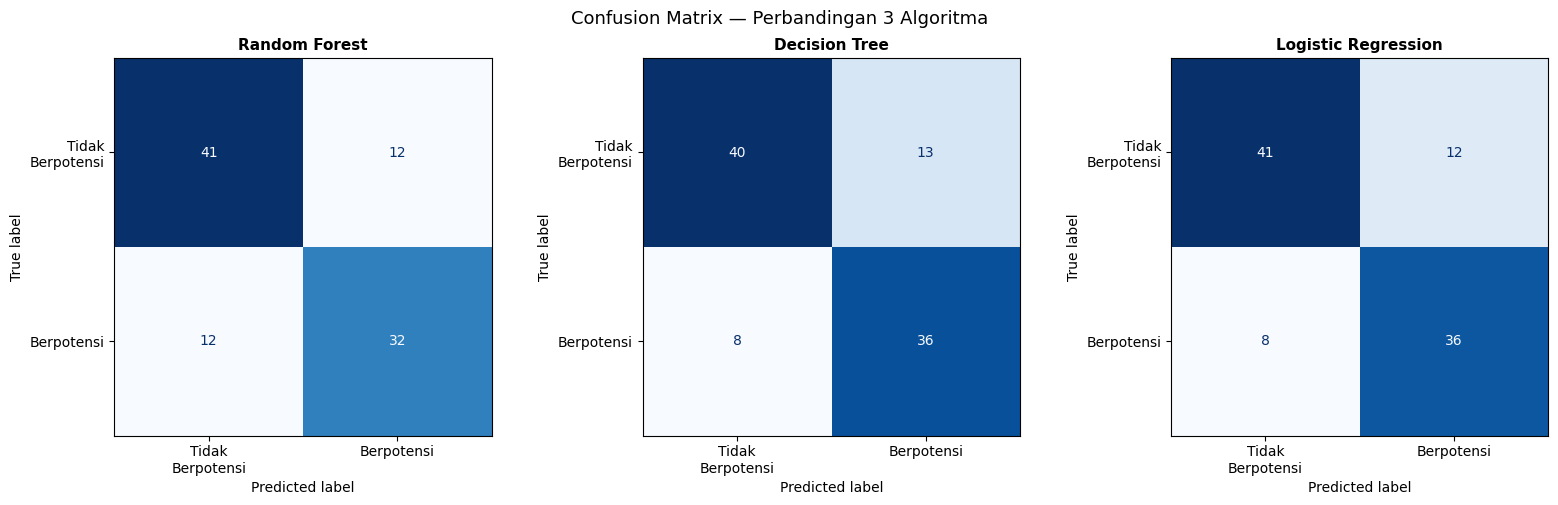

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
models_eval = [
    ('Random Forest',       rf_pred),
    ('Decision Tree',       dt_pred),
    ('Logistic Regression', lr_pred),
]
for ax, (name, pred) in zip(axes, models_eval):
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(cm, display_labels=['Tidak\nBerpotensi', 'Berpotensi'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name, fontsize=11, fontweight='bold')

plt.suptitle('Confusion Matrix — Perbandingan 3 Algoritma', fontsize=13)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/confusion_matrix.png", dpi=150, bbox_inches='tight')
plt.show()


## 📈 Sel 16 — ROC Curve (3 Model)

AUC Decision Tree: 0.8698542024013721


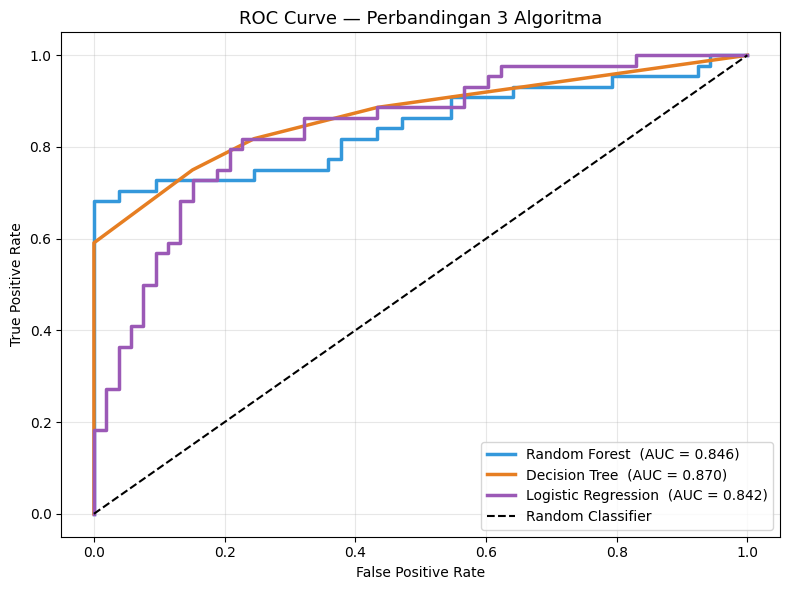

In [19]:
# Recompute dt_prob dengan data terbaru
dt_model.fit(X_train, y_train)
dt_pred = dt_model.predict(X_test)
dt_prob = dt_model.predict_proba(X_test)[:, 1]

print("AUC Decision Tree:", roc_auc_score(y_test, dt_prob))
plt.figure(figsize=(8, 6))
for name, prob, color in [
    ('Random Forest',       rf_prob, '#3498db'),
    ('Decision Tree',       dt_prob, '#e67e22'),
    ('Logistic Regression', lr_prob, '#9b59b6'),
]:
    fpr, tpr, _ = roc_curve(y_test, prob)
    auc = roc_auc_score(y_test, prob)
    plt.plot(fpr, tpr, color=color, lw=2.5, label=f'{name}  (AUC = {auc:.3f})')

plt.plot([0,1],[0,1],'k--', lw=1.5, label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve — Perbandingan 3 Algoritma', fontsize=13)
plt.legend(loc='lower right')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/roc_curve.png", dpi=150, bbox_inches='tight')
plt.show()


## 🔄 Sel 17 — Cross-Validation (5-Fold Stratified)

Algoritma                  Fold 1  Fold 2  Fold 3  Fold 4  Fold 5     Mean     Std
--------------------------------------------------------------------------------
Random Forest              0.8454  0.8454  0.7812  0.7917  0.6979  0.7923  0.0542
Decision Tree              0.4845  0.8144  0.5312  0.5208  0.5417  0.5785  0.1195
Logistic Regression        0.8247  0.8454  0.7396  0.8438  0.6875  0.7882  0.0635


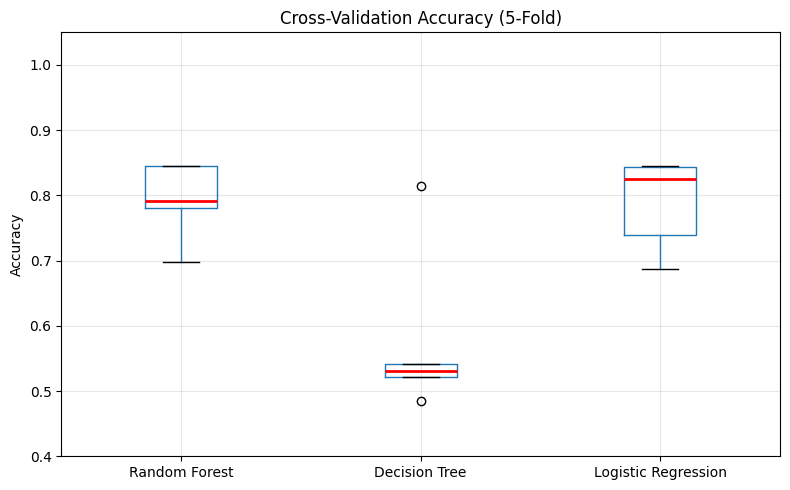

In [20]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
cv_results = {}

print(f"{'Algoritma':<25} {'Fold 1':>7} {'Fold 2':>7} {'Fold 3':>7} {'Fold 4':>7} {'Fold 5':>7}  {'Mean':>7} {'Std':>7}")
print("-" * 80)

for name, model in [
    ('Random Forest',       rf_model),
    ('Decision Tree',       dt_model),
    ('Logistic Regression', lr_model),
]:
    scores = cross_val_score(model, X_processed, y, cv=cv, scoring='accuracy')
    cv_results[name] = scores
    folds = '  '.join([f'{s:.4f}' for s in scores])
    print(f"{name:<25}  {folds}  {scores.mean():.4f}  {scores.std():.4f}")

# Boxplot
plt.figure(figsize=(8, 5))
df_cv = pd.DataFrame(cv_results)
df_cv.boxplot(medianprops={'color': 'red', 'linewidth': 2})
plt.title('Cross-Validation Accuracy (5-Fold)')
plt.ylabel('Accuracy')
plt.ylim(0.4, 1.05)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/cross_validation.png", dpi=150, bbox_inches='tight')
plt.show()

## 🏆 Sel 19 — Tabel Perbandingan & Visualisasi Akhir

  TABEL PERBANDINGAN PERFORMA ALGORITMA


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
Algoritma,,,,,
Random Forest,0.7526,0.7273,0.7273,0.7273,0.8456
Decision Tree,0.7835,0.7347,0.8182,0.7742,0.8699
Logistic Regression,0.7938,0.7500,0.8182,0.7826,0.8418



🏆 Model Terbaik: Logistic Regression
   Accuracy    : 0.7938
   Precision   : 0.7500
   Recall      : 0.8182
   F1-Score    : 0.7826
   AUC-ROC     : 0.8418


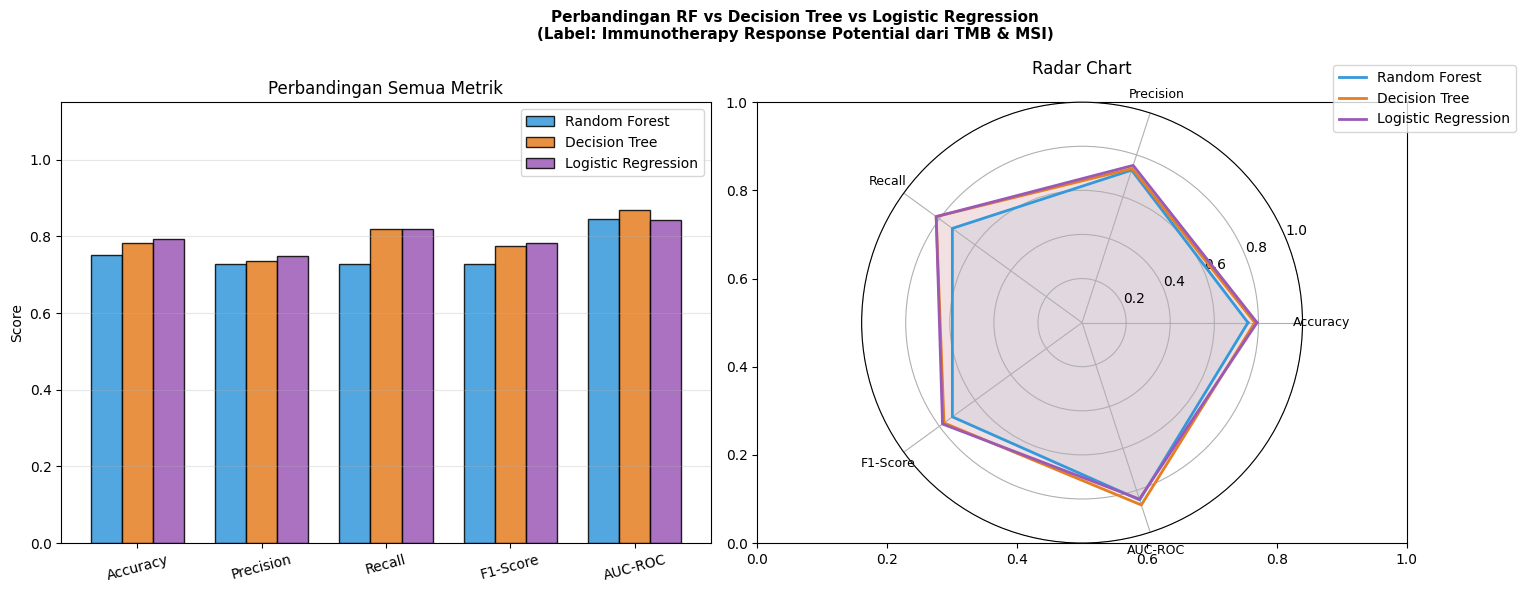

In [21]:
comparison = pd.DataFrame({
    'Algoritma': ['Random Forest', 'Decision Tree', 'Logistic Regression'],
    'Accuracy' : [rf_metrics['Accuracy'],  dt_metrics['Accuracy'],  lr_metrics['Accuracy']],
    'Precision': [rf_metrics['Precision'], dt_metrics['Precision'], lr_metrics['Precision']],
    'Recall'   : [rf_metrics['Recall'],    dt_metrics['Recall'],    lr_metrics['Recall']],
    'F1-Score' : [rf_metrics['F1-Score'],  dt_metrics['F1-Score'],  lr_metrics['F1-Score']],
    'AUC-ROC'  : [rf_metrics['AUC-ROC'],   dt_metrics['AUC-ROC'],   lr_metrics['AUC-ROC']],
}).set_index('Algoritma').round(4)

print("=" * 65)
print("  TABEL PERBANDINGAN PERFORMA ALGORITMA")
print("=" * 65)
display(comparison)

best = comparison['Accuracy'].idxmax()
print(f"\n🏆 Model Terbaik: {best}")
for m in ['Accuracy','Precision','Recall','F1-Score','AUC-ROC']:
    print(f"   {m:<12}: {comparison.loc[best, m]:.4f}")

# ── Visualisasi grouped bar + radar ──────────────────────────────
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'AUC-ROC']
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

x = np.arange(len(metrics))
width = 0.25
algo_colors = ['#3498db', '#e67e22', '#9b59b6']

for i, (algo, color) in enumerate(zip(comparison.index, algo_colors)):
    axes[0].bar(x + i*width, comparison.loc[algo, metrics],
                width, label=algo, color=color, edgecolor='black', alpha=0.85)
axes[0].set_xticks(x + width)
axes[0].set_xticklabels(metrics, rotation=15)
axes[0].set_ylabel('Score')
axes[0].set_title('Perbandingan Semua Metrik')
axes[0].legend()
axes[0].set_ylim(0, 1.15)
axes[0].grid(axis='y', alpha=0.3)

# Radar chart
angles = np.linspace(0, 2*np.pi, len(metrics), endpoint=False).tolist()
angles += angles[:1]
ax_radar = plt.subplot(122, polar=True)
for algo, color in zip(comparison.index, algo_colors):
    vals = comparison.loc[algo, metrics].tolist()
    vals += vals[:1]
    ax_radar.plot(angles, vals, color=color, lw=2, label=algo)
    ax_radar.fill(angles, vals, color=color, alpha=0.1)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(metrics, size=9)
ax_radar.set_ylim(0, 1)
ax_radar.set_title('Radar Chart', pad=20)
ax_radar.legend(loc='upper right', bbox_to_anchor=(1.5, 1.1))

plt.suptitle('Perbandingan RF vs Decision Tree vs Logistic Regression\n(Label: Immunotherapy Response Potential dari TMB & MSI)',
             fontsize=11, fontweight='bold')
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/perbandingan_algoritma.png", dpi=150, bbox_inches='tight')
plt.show()


## 💾 Sel 20 — Simpan Semua Hasil ke Google Drive

In [22]:
# Simpan tabel perbandingan
comparison.to_csv(f"{OUTPUT_DIR}/tabel_perbandingan_metrik.csv")

# Simpan classification report lengkap
with open(f"{OUTPUT_DIR}/classification_reports.txt", 'w') as f:
    f.write("LABEL: Immunotherapy Response Potential\n")
    f.write(f"Dibuat dari: TMB >= {TMB_THRESHOLD} OR MSIsensor >= {MSI_THRESHOLD}\n")
    f.write(f"Total sampel: {n_total} | Positif: {n_pos} | Negatif: {n_neg}\n")
    f.write(f"Fitur training ({len(available_features)}): {available_features}\n")
    f.write("Anti-leakage: TMB & MSI DIHAPUS dari fitur training\n\n")
    for name, pred in [
        ('Random Forest', rf_pred),
        ('Decision Tree', dt_pred),
        ('Logistic Regression', lr_pred),
    ]:
        f.write(f"{'='*55}\n  {name}\n{'='*55}\n")
        f.write(classification_report(y_test, pred,
                target_names=['Tidak Berpotensi', 'Berpotensi']))
        f.write("\n")

# Simpan dataset berlabel (untuk referensi)
df_labeled.to_csv(f"{OUTPUT_DIR}/tcga_berlabel.csv", index=False)

print("✅ Semua hasil tersimpan!")
print(f"\n📁 Lokasi: {OUTPUT_DIR}")
print()
for fname in sorted(os.listdir(OUTPUT_DIR)):
    kb = os.path.getsize(f"{OUTPUT_DIR}/{fname}") / 1024
    print(f"   📄 {fname:<45} {kb:>7.1f} KB")

print()
print("=" * 55)
print("  RINGKASAN AKHIR PENELITIAN")
print("=" * 55)
print(f"  Dataset     : TCGA Ovarian Cancer ({n_total} sampel)")
print(f"  Label       : TMB >= {TMB_THRESHOLD} OR MSIsensor >= {MSI_THRESHOLD}")
print(f"  Positif (1) : {n_pos} sampel ({n_pos/n_total*100:.1f}%)")
print(f"  Negatif (0) : {n_neg} sampel ({n_neg/n_total*100:.1f}%)")
print(f"  Fitur       : {len(available_features)} fitur (tanpa TMB & MSI)")
print(f"  Split       : 80% train / 20% test")
print()
print(f"  {'Algoritma':<25} {'Accuracy':>9} {'F1-Score':>9} {'AUC-ROC':>9}")
print("  " + "-" * 55)
for algo in comparison.index:
    marker = " 🏆" if algo == best else ""
    print(f"  {algo:<25} {comparison.loc[algo,'Accuracy']:>9.4f} {comparison.loc[algo,'F1-Score']:>9.4f} {comparison.loc[algo,'AUC-ROC']:>9.4f}{marker}")


✅ Semua hasil tersimpan!

📁 Lokasi: /content/drive/MyDrive/randomforest/data/hasil_penelitian

   📄 classification_reports.txt                        1.9 KB
   📄 confusion_matrix.png                             54.8 KB
   📄 cross_validation.png                             34.6 KB
   📄 decision_tree_viz.png                           193.7 KB
   📄 distribusi_fitur.png                             76.9 KB
   📄 distribusi_label.png                             87.9 KB
   📄 feature_importance.png                           54.1 KB
   📄 korelasi.png                                    343.4 KB
   📄 missing_values.png                              122.3 KB
   📄 perbandingan_algoritma.png                      235.1 KB
   📄 roc_curve.png                                    86.9 KB
   📄 tabel_perbandingan_metrik.csv                     0.2 KB
   📄 tcga_berlabel.csv                               226.0 KB
   📄 tcga_preprocessed.csv                           109.9 KB

  RINGKASAN AKHIR PENELITIAN
  Datas